# 03 — Konstrukcija portfelja unaprijednim hodom

Faza 4 projekta s kliznim prozorom.

Za svaki klizni prozor rješavamo pet portfelja na razdoblju treniranja i
primjenjujemo dobivene težine na sljedećih 12 testnih mjeseci:

| # | Portfelj | Napomene |
|---|-----------|-------|
| 0 | Jednake težine | referenca 1/N |
| 1 | Minimalna varijanca | Ledoit-Wolf kovarijanca, `w_max=0.02` |
| 2 | Min. varijanca, ograničenje sektora | GICS sektor, `group_cap=0.15` |
| 3 | Min. varijanca, ograničenje korelacijskih klastera | Hijerarhijsko klasteriranje potpunom vezom na korelacijama razdoblja treniranja |
| 4 | Min. varijanca, ograničenje faktorskih klastera | Hijerarhijsko Wardovo klasteriranje standardiziranih faktorskih beta |


In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

from src.backtest import PORTFOLIO_NAMES, generate_rolling_windows, run_walk_forward
from src.utils import (
    FIGURES_DIR,
    GROUP_CAP,
    PROCESSED_DATA_DIR,
    TABLES_DIR,
    W_MAX,
    ensure_dirs,
    set_seed,
)

ensure_dirs()
set_seed()


In [2]:
monthly_returns = pd.read_csv(
    PROCESSED_DATA_DIR / "monthly_returns.csv", index_col=0, parse_dates=True
)
factor_exposures = pd.read_csv(PROCESSED_DATA_DIR / "factor_exposures.csv")
factor_clusters = pd.read_csv(PROCESSED_DATA_DIR / "factor_clusters.csv")
correlation_clusters = pd.read_csv(PROCESSED_DATA_DIR / "correlation_clusters.csv")
metadata = pd.read_csv(PROCESSED_DATA_DIR / "metadata.csv")
windows = generate_rolling_windows()
print(f"{len(windows)} kliznih prozora; w_max={W_MAX}, group_cap={GROUP_CAP}")


16 kliznih prozora; w_max=0.02, group_cap=0.15


## 3.1 Pokreni unaprijedni backtest (Ledoit-Wolf primarni)


In [3]:
result = run_walk_forward(
    monthly_returns=monthly_returns,
    factor_exposures=factor_exposures,
    factor_clusters=factor_clusters,
    correlation_clusters=correlation_clusters,
    metadata=metadata,
    windows=windows,
    cov_estimator="ledoit_wolf",
    w_max=W_MAX,
    group_cap=GROUP_CAP,
)
weights_panel = result["weights_panel"]
port_returns_panel = result["port_returns_panel"]
portfolio_status = result["portfolio_status"]

weights_panel.to_csv(TABLES_DIR / "weights_panel.csv", index=False)
port_returns_panel.to_csv(TABLES_DIR / "port_returns_panel.csv", index_label="date")
portfolio_status.to_csv(TABLES_DIR / "portfolio_status.csv", index=False)

print("Sažetak statusa portfelja:")
print(portfolio_status.groupby(["portfolio", "status"]).size().unstack(fill_value=0))
print()
print("Mjeseci prinosa portfelja:", port_returns_panel.shape)


2026-06-04 21:23:35,473 WARNING Portfelj min_var_corr_cluster nije uspio u prozoru 2009-12: Grupna ograničenja su neizvediva: kombinirani ograničeni kapacitet grupa je 0.940000, ispod 1.
2026-06-04 21:23:47,232 WARNING Portfelj min_var_corr_cluster nije uspio u prozoru 2018-12: Grupna ograničenja su neizvediva: kombinirani ograničeni kapacitet grupa je 0.960000, ispod 1.


Sažetak statusa portfelja:
status                  failed: ValueError: Grupna ograničenja su neizvediva: kombinirani ograničeni kapacitet grupa je 0.940000, ispod 1.  \
portfolio                                                                                                                                    
equal_weight                                                            0                                                                    
min_var                                                                 0                                                                    
min_var_corr_cluster                                                    1                                                                    
min_var_factor_cluster                                                  0                                                                    
min_var_sector                                                          0                                                

## 3.2 Dijagnostika ograničenja


In [4]:
group_cap_check_rows = []
for window_label, window_weights in weights_panel.groupby("train_window"):
    for portfolio_name, sub in window_weights.groupby("portfolio"):
        if portfolio_name == "equal_weight":
            continue
        if portfolio_name == "min_var_factor_cluster":
            join = sub.merge(
                factor_clusters[["train_window", "ticker", "factor_cluster"]],
                on=["train_window", "ticker"],
                how="left",
            )
            grouped = join.groupby("factor_cluster")["weight"].sum()
        elif portfolio_name == "min_var_corr_cluster":
            join = sub.merge(
                correlation_clusters[["train_window", "ticker", "correlation_cluster"]],
                on=["train_window", "ticker"],
                how="left",
            )
            grouped = join.groupby("correlation_cluster")["weight"].sum()
        elif portfolio_name == "min_var_sector":
            sector_map = metadata.set_index("ticker")["sector"]
            join = sub.assign(sector=sub["ticker"].map(sector_map))
            grouped = join.groupby("sector")["weight"].sum()
        else:
            continue
        group_cap_check_rows.append(
            {
                "train_window": window_label,
                "portfolio": portfolio_name,
                "max_w": sub["weight"].max(),
                "max_group_sum": float(grouped.max()) if not grouped.empty else float("nan"),
            }
        )
constraint_diag = pd.DataFrame(group_cap_check_rows)
print("Maksimalna pojedinačna težina po portfelju (treba biti ≤ {:.4f}):".format(W_MAX + 1e-6))
print(constraint_diag.groupby("portfolio")["max_w"].describe()[["max", "mean", "min"]])
print()
print("Maksimalna grupna suma po portfelju (treba biti ≤ {:.4f}):".format(GROUP_CAP + 1e-6))
print(constraint_diag.groupby("portfolio")["max_group_sum"].describe()[["max", "mean", "min"]])
constraint_diag.to_csv(TABLES_DIR / "portfolio_constraint_diagnostics.csv", index=False)


Maksimalna pojedinačna težina po portfelju (treba biti ≤ 0.0200):
                         max  mean   min
portfolio                               
min_var_corr_cluster    0.02  0.02  0.02
min_var_factor_cluster  0.02  0.02  0.02
min_var_sector          0.02  0.02  0.02

Maksimalna grupna suma po portfelju (treba biti ≤ 0.1500):
                         max  mean   min
portfolio                               
min_var_corr_cluster    0.15  0.15  0.15
min_var_factor_cluster  0.15  0.15  0.15
min_var_sector          0.15  0.15  0.15


## 3.3 Brzi pregled krivulje kapitala (kumulativno složeno)


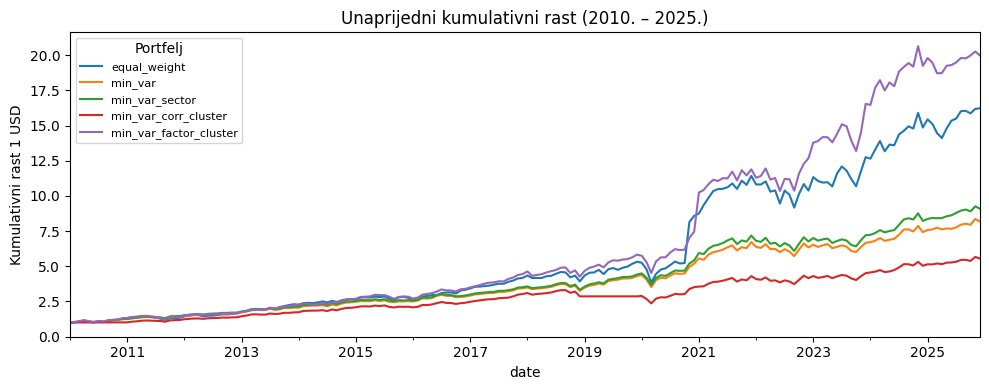

In [5]:
cumulative = (1.0 + port_returns_panel.fillna(0.0)).cumprod()
fig, ax = plt.subplots(figsize=(10, 4))
cumulative.plot(ax=ax)
ax.set_title("Unaprijedni kumulativni rast (2010. – 2025.)")
ax.set_ylabel("Kumulativni rast 1 USD")
ax.legend(title="Portfelj", fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_cumulative_growth_preview.png", dpi=150)
plt.show()
